In [31]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import prettytable as pt
from matplotlib import pyplot as plt

from rhoova.Client import *

config = ClientConfig("iFpuqa43s0neL7NrF3fWb", "TYzuSHGUUe-B4UguM4k5wj4PhWSgZxwq")
api = Api(config)

yielddata = pd.read_csv("/data/yielddata.csv")
yielddata = yielddata.replace(np.nan, '', regex=True) 


In [32]:
# Fix parameters for building yield curve instruments
instrumentsconfig={
            "DEPO": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360"
            },
            "FUTURES": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360",
                "market": "IMM",
                "usedates": True
            },
            "IRS": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360",
                "frequency": "Annual"
            }
        } 

In [33]:
# Fix parameters for building yield curve

yieldcurveconfig={
        "settlementDays": 2,
        "intpMethod": "LINEAR",
        "currency": "USD",
        "calendar": "UnitedStates",
        "dayCounter": "Actual360",
        "period": "3M",
        "instruments":instrumentsconfig,}

In [34]:
result =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

/var/folders/2y/00gspyq11l77jgf8k9y6z73w0000gn/T/ipykernel_50801/3292948748.py:5: FutureWarning: Using short name for 'orient' is deprecated. Only the options: ('dict', list, 'series', 'split', 'records', 'index') will be used in a future version. Use one of the above to silence this warning.
  "yieldData": yielddata.to_dict('r')


In [35]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovayieldcurvedicts = {}
rhoovayieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovayieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovayieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [36]:
bloombergzerorates=[0.13026,0.13026,0.12933,0.12543,0.1399,0.14339,0.15367,0.17113,0.2277,0.42095,0.66016,0.88188,
                    1.08274,1.25338,1.38811,1.49866,1.59246,1.67237,1.74239,1.88604,2.00444,2.04047,2.04536,
                    1.94349,1.81266]
bloombergdiscountrates=[1.00,0.999661,0.999635,0.999334,0.998908,0.998524,0.998006,0.997354,0.99545,0.98744,
                        0.973922,0.956841,0.937073,0.915908,0.894827,0.87375,0.852713,0.831854,0.811132,0.753435,
                        0.669541,0.600223,0.541152,0.459309,0.403764]

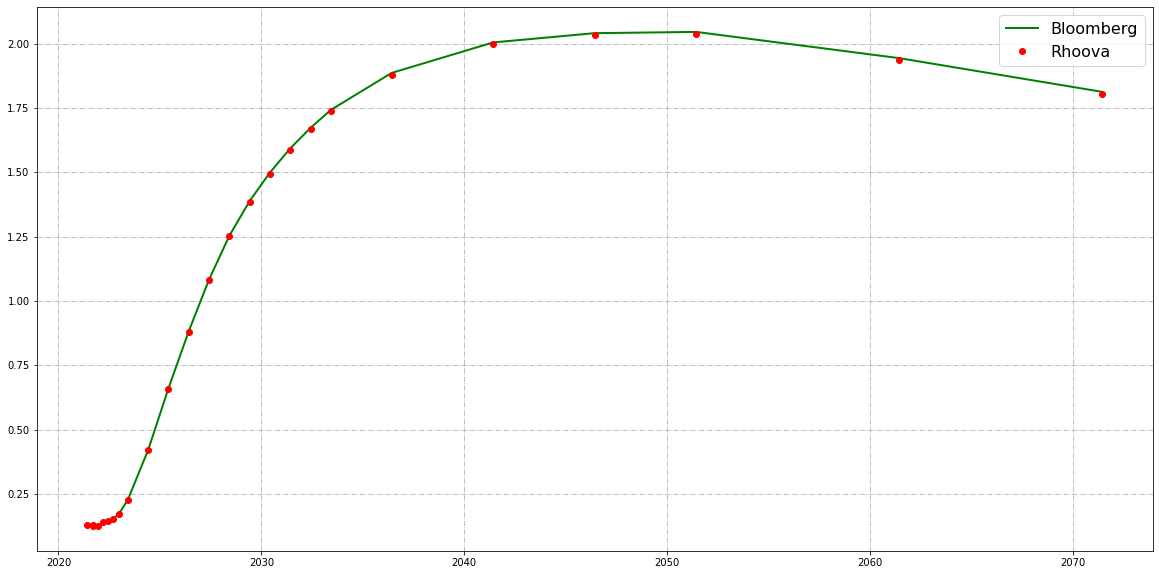

In [37]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =bloombergzerorates
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)
#
leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

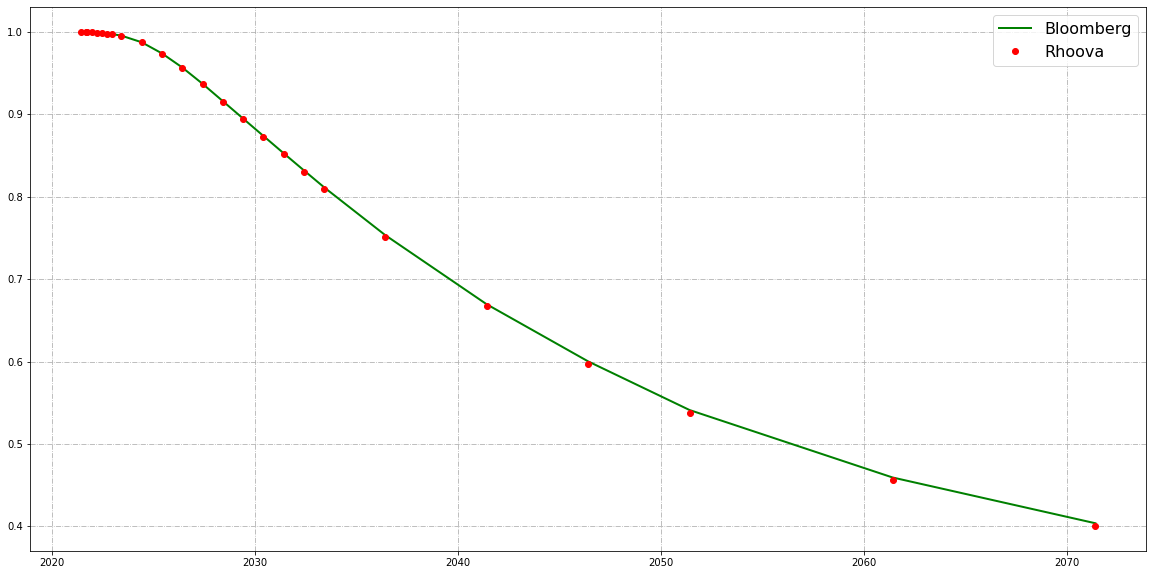

In [38]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y1 =bloombergdiscountrates
y2 = list(rhoovayieldcurvediscounts.values())

ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=12)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [39]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,bloombergzerorates[i],rhoovayieldcurvediscounts.get(key),bloombergdiscountrates[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.130260   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130260   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129330   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.124726     |   0.125430   |       0.999328       |   0.999334   |
| 2022-03-15 |     0.139854     |   0.139900   |       0.998897       |   0.998908   |
| 2022-06-16 |     0.144188     |   0.143390   |       0.998491       |   0.998524   |
| 2022-09-15 |     0.153638     |   0.153670   |       0.998005       |   0.998006   |
| 2022-12-21 |     0.172117     |   0.171130   |       0.997302       |   0.997354   |
| 2023-06-05 |     0.227535     |   0.22770

In [40]:
yieldcurveconfig['applyShock']=[{
                "tenor": "2Y",
                "shockValue": 100
            },
            {
                "tenor": "10Y",
                "shockValue": 200
            }]

In [41]:
result =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

/var/folders/2y/00gspyq11l77jgf8k9y6z73w0000gn/T/ipykernel_50801/3292948748.py:5: FutureWarning: Using short name for 'orient' is deprecated. Only the options: ('dict', list, 'series', 'split', 'records', 'index') will be used in a future version. Use one of the above to silence this warning.
  "yieldData": yielddata.to_dict('r')


In [42]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovayieldcurvedicts = {}
rhoovayieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovayieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovayieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [43]:
bloombergshiftedmarketrates=[0.1285,0.127450119,0.119375077,0.168457736,0.152206235,0.190519723,0.258569906,
                             1.227600001,0.421499997,0.658000499,0.875930011,1.073450506,1.239165008,1.369239986,
                             1.474700034,3.564020038,1.640365541,1.7051,1.83950001,1.951399982,1.99000001,
                             2.001249969,1.93870002,1.85363996]
bloombergshiftedzerorates=[0.1314,0.130262638,0.129325564,0.125427219,0.139902239,0.143384512,0.153666499,
                           0.171127066,1.233855314,0.419400528,0.657362026,0.878395501,1.080525856,1.251133521,
                           1.386437767,1.496877363,4.007172201,1.637389258,1.707879251,1.8557922,1.980338665,
                           2.020502028,2.028382992,1.931971567,1.805295275]
bloombergshifteddiscountrates=[1.00,0.999661018,0.99963512,0.999333568,0.998908209,0.998524033,0.99800643,
                               0.997354552,0.975591905,0.98748546,0.974030666,0.957007701,0.93719758,0.916051971,
                               0.894946812,0.873889813,0.66969239,0.835063593,0.814501128,0.756863617,0.672778577,
                               0.603229448,0.543916534,0.461430517,0.405254036]

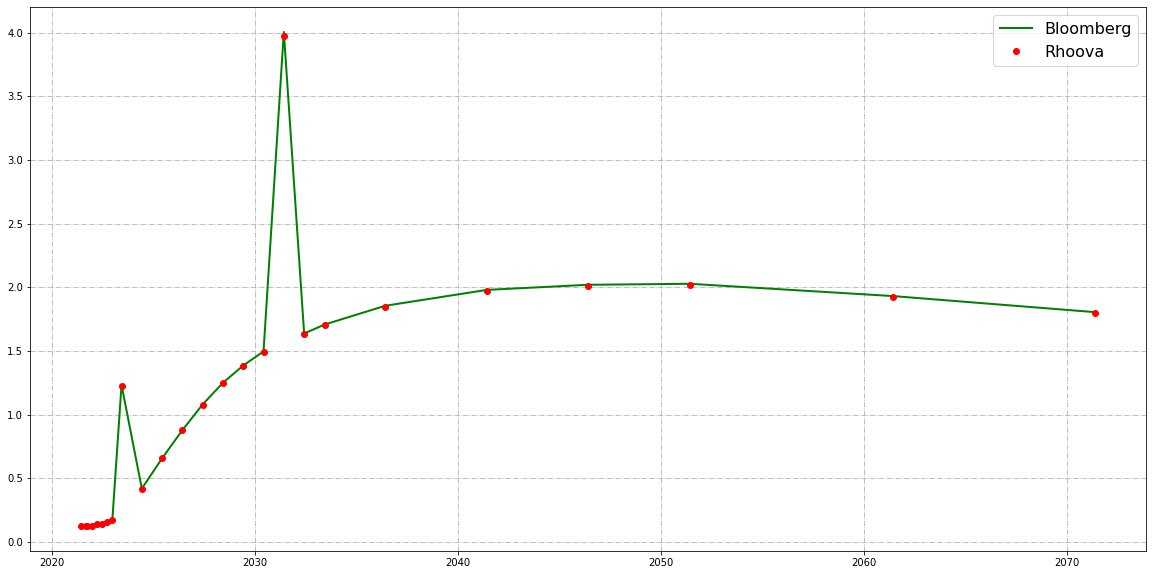

In [44]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =bloombergshiftedzerorates
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

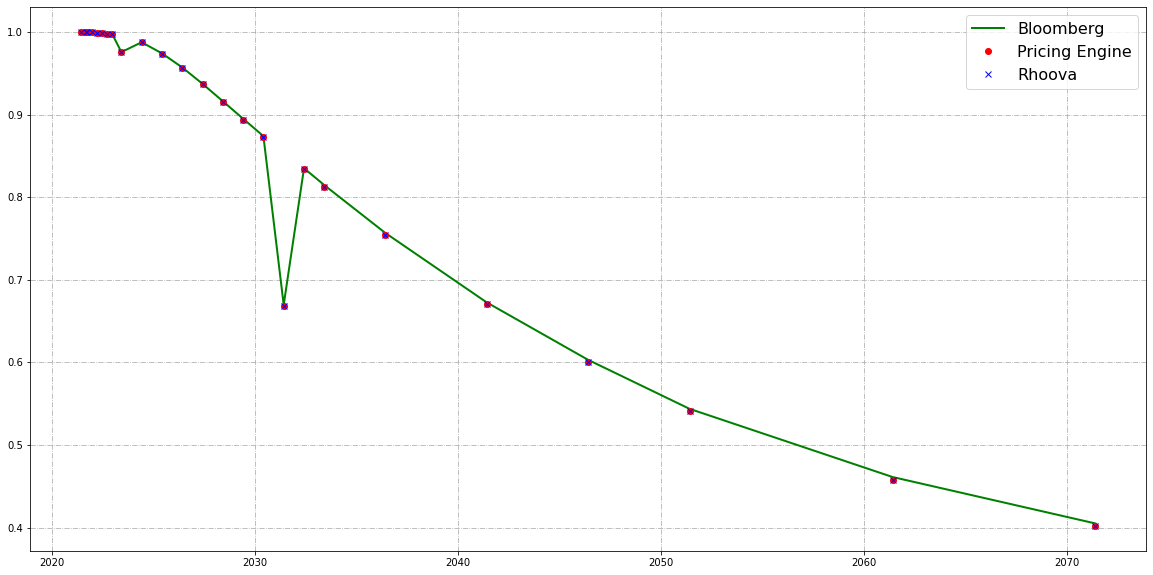

In [45]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y1 =bloombergshifteddiscountrates
y2 = list(rhoovayieldcurvediscounts.values())
y3 = list(rhoovayieldcurvediscounts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Pricing Engine', linewidth=8)
ax.plot(x,y3, 'bx', label='Rhoova', linewidth=4)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [46]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,bloombergshiftedzerorates[i],rhoovayieldcurvediscounts.get(key),bloombergshifteddiscountrates[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.131400   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130263   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129326   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.124726     |   0.125427   |       0.999328       |   0.999334   |
| 2022-03-15 |     0.139854     |   0.139902   |       0.998897       |   0.998908   |
| 2022-06-16 |     0.144188     |   0.143385   |       0.998491       |   0.998524   |
| 2022-09-15 |     0.153638     |   0.153666   |       0.998005       |   0.998006   |
| 2022-12-21 |     0.172117     |   0.171127   |       0.997302       |   0.997355   |
| 2023-06-05 |     1.226913     |   1.23385

In [47]:
# Fix parameters for building yield curve

yieldcurveconfig['applyShock']=[{
                "tenor": "9M",
                "shockValue": 100
            },
            {
                "tenor": "2Y",
                "shockValue": 75
            }]

In [48]:
result =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

/var/folders/2y/00gspyq11l77jgf8k9y6z73w0000gn/T/ipykernel_50801/3292948748.py:5: FutureWarning: Using short name for 'orient' is deprecated. Only the options: ('dict', list, 'series', 'split', 'records', 'index') will be used in a future version. Use one of the above to silence this warning.
  "yieldData": yielddata.to_dict('r')


In [49]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovayieldcurvedicts = {}
rhoovayieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovayieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovayieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [50]:
bloombergshiftedmarketrates2=[0.1285,0.127450119,1.119375077,0.168457736,0.152206235,0.190519723,0.258569906,
                              0.977600001,0.421499997,0.658000499,0.875930011,1.073450506,1.239165008,1.369239986,
                              1.474700034,1.564020038,1.640365541,1.7051,1.83950001,1.951399982,1.99000001,
                              2.001249969,1.93870002,1.85363996]
bloombergshiftedzerorates2=[0.1314,0.130262638,0.129325564,0.600271092,0.463129296,0.388383744,0.348011882,
                            0.334170803,0.979536089,0.419462015,0.657434593,0.878473525,1.080606403,1.25121403,
                            1.38651643,1.496953385,1.59114944,1.671791597,1.740912902,1.884895529,2.004024537,
                            2.040031831,2.04481215,1.943518053,1.813615638]
bloombergshifteddiscountrates2=[1.00,0.999661018,0.99963512,0.996814602,0.996390316,0.996007108,0.99549081,
                                0.994840575,0.980573614,0.987483637,0.974027837,0.957003965,0.937193048,0.916046802,
                                0.894941176,0.87388383,0.85282396,0.831907116,0.811275134,0.753564327,0.669596872,
                                0.600289461,0.541240353,0.459302527,0.403570504]

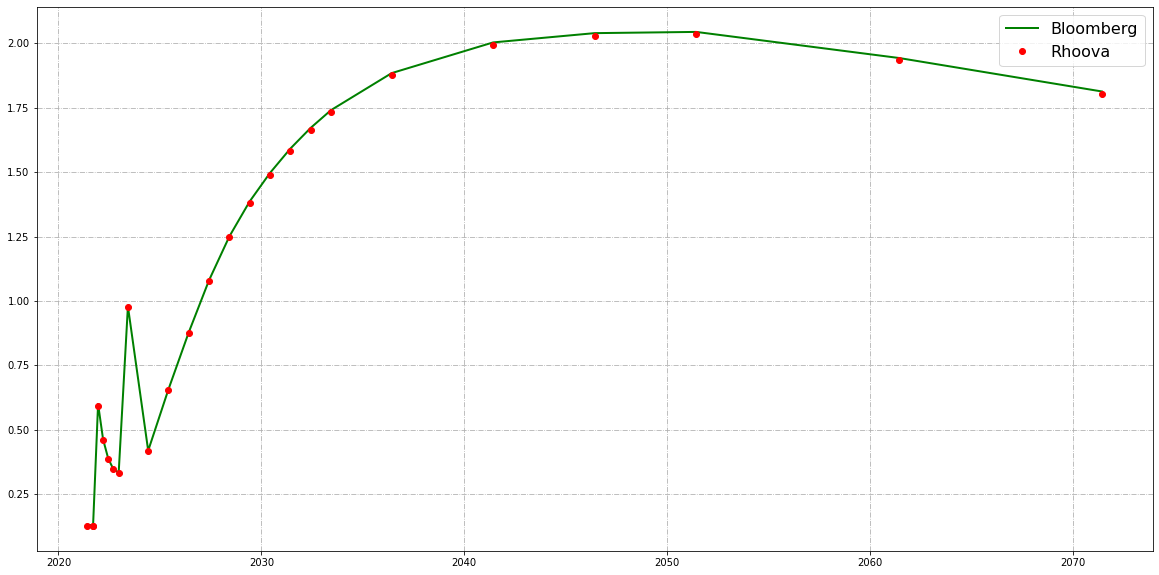

In [51]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =bloombergshiftedzerorates2
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

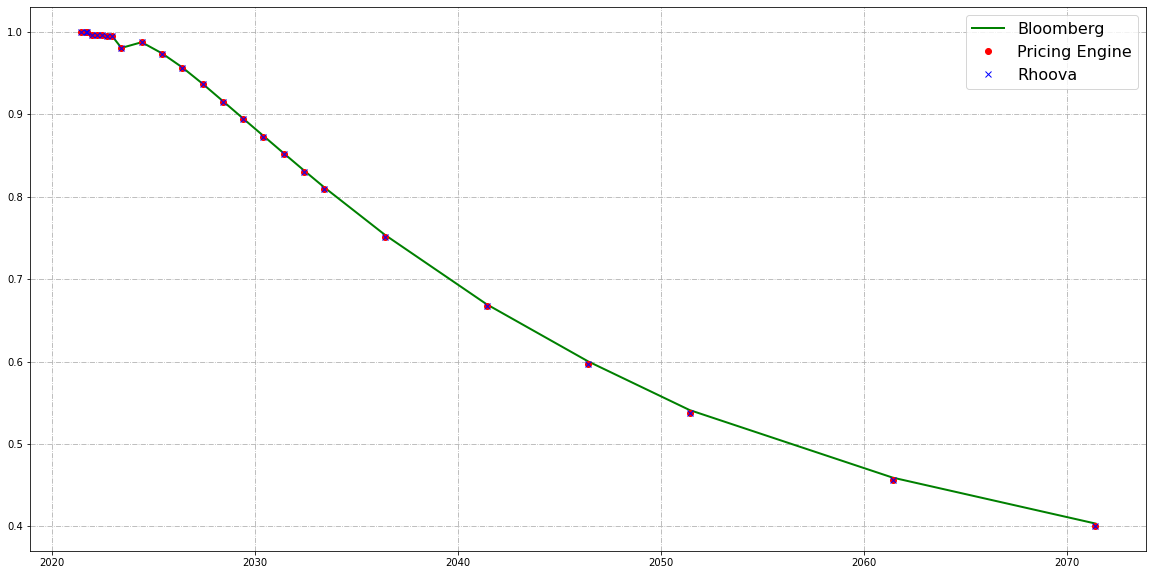

In [52]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y1 =bloombergshifteddiscountrates2
y2 = list(rhoovayieldcurvediscounts.values())
y3 = list(rhoovayieldcurvediscounts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Pricing Engine', linewidth=8)
ax.plot(x,y3, 'bx', label='Rhoova', linewidth=4)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [53]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,bloombergshiftedzerorates2[i],rhoovayieldcurvediscounts.get(key),bloombergshifteddiscountrates2[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.131400   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130263   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129326   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.593062     |   0.600271   |       0.996809       |   0.996815   |
| 2022-03-15 |     0.459773     |   0.463129   |       0.996379       |   0.996390   |
| 2022-06-16 |     0.385397     |   0.388384   |       0.995972       |   0.996007   |
| 2022-09-15 |     0.348110     |   0.348012   |       0.995485       |   0.995491   |
| 2022-12-21 |     0.333552     |   0.334171   |       0.994779       |   0.994841   |
| 2023-06-05 |     0.975788     |   0.97953